# 03 — Laboratoire : tester le modèle sur une saison complète
1. **Saison figée** : le modèle est entraîné au 1er juillet et prédit toute la saison sans voir ses résultats.
2. **Semaine par semaine** : chaque lundi, le modèle est ré-entraîné sur tout ce qui précède puis prédit la semaine — répétition générale du suivi en direct.

Tous les tableaux et graphiques sont enregistrés dans `results/` (et dans un classeur Excel) pour le rapport.

In [1]:
# ── Installation : fonctionne dans Colab (clone le dépôt) comme en local (depuis le dossier notebooks/) ──
import os, sys
DEPOT = "https://github.com/abdelkbir1243/football-prediction-stat.git"   # ← adapter si le dépôt a un autre nom
if os.path.exists("../footpred"):
    os.chdir("..")
elif not os.path.exists("footpred"):
    os.system(f"git clone -q {DEPOT}"); os.chdir("football-prediction-stat")
    os.system("pip -q install -r requirements.txt")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from footpred import preparer, labo, journal, config
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

In [2]:
SAISON = 2025                 # 2025 = 2025/26 ; essayer 2021 … 2025
LIGUES = None                 # ex. ["SP1", "F1"] pour ne tester que Liga + Ligue 1
pred = preparer(); d = pred.d

## 1. Saison figée — comparaison des modèles

/tmp/claude-0/-home-claude/75abb860-c445-5888-96a1-2e500f7f5c5d/scratchpad/repo/footpred/labo.py:147: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax[1].plot(g.p, g.o, "-o", lw=2, ms=6, color=COUL[nom], mec="white", mew=1.5, label=nom, ls="--" if nom == "Cotes" else "-")
/tmp/claude-0/-home-claude/75abb860-c445-5888-96a1-2e500f7f5c5d/scratchpad/repo/footpred/labo.py:147: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax[1].plot(g.p, g.o, "-o", lw=2, ms=6, color=COUL[nom], mec="white", mew=1.5, label=nom, ls="--" if nom == "Cotes" else "-")



■ 1X2


,matchs,log loss,RPS,Brier,ECE,bon résultat,skill vs fréquences
Fréquences,1737,1.0723,0.2292,0.6486,0.0000,0.4393,0.0000
Elo seul,1737,0.9972,0.2035,0.5952,0.0271,0.5124,0.0700
v3,1737,0.9911,0.2015,0.5910,0.0311,0.5153,0.0757
v4,1737,0.9902,0.2011,0.5904,0.0217,0.5112,0.0765
Cotes,1737,0.9802,0.1980,0.5836,0.0291,0.5325,0.0858



■ tests


,Δ log loss ×1e3,IC bas,IC haut,significatif
comparaison,,,,
v4 − v3,-0.8815,-3.2311,1.7506,False
v4 − Elo seul,-7.0329,-12.1577,-1.8804,True
v4 − Cotes,9.9446,3.2839,16.7849,True
v4 − v3 (score exact),-2.4933,-7.7804,2.8400,False
"v4 − v3 (over 2,5)",-1.0490,-5.1931,3.3831,False


...

,Elo seul,v3,v4,Cotes
Division,,,,
Bundesliga,0.9672,0.9588,0.9568,0.9514
Liga,0.9818,0.9745,0.9720,0.9674
Ligue 1,0.9950,0.9884,0.9890,0.9747
Premier League,1.0366,1.0308,1.0278,1.0185
Serie A,0.9991,0.9958,0.9983,0.9823



■ par_saison


,Elo seul,v3,v4,Cotes
Season,,,,
2025,0.9972,0.9911,0.9902,0.9802



■ surprises


,Date,Ligue,HomeTeam,AwayTeam,Score,P1,PX,P2,p_résultat
0,2026-01-24,Bundesliga,Bayern Munich,Augsburg,1-2,0.884,0.086,0.031,0.031
1,2026-03-02,Liga,Real Madrid,Getafe,0-1,0.813,0.142,0.045,0.045
2,2025-12-07,Liga,Real Madrid,Celta,0-2,0.812,0.130,0.058,0.058
3,2026-05-02,Bundesliga,Bayern Munich,Heidenheim,3-3,0.903,0.073,0.024,0.073
4,2025-08-31,Serie A,Inter,Udinese,1-2,0.738,0.184,0.078,0.078
5,2026-01-04,Ligue 1,Marseille,Nantes,0-2,0.775,0.147,0.078,0.078
6,2025-10-25,Premier League,Chelsea,Sunderland,1-2,0.752,0.170,0.078,0.078
7,2025-12-14,Bundesliga,Bayern Munich,Mainz,2-2,0.884,0.087,0.030,0.087
8,2026-04-19,Ligue 1,Paris SG,Lyon,1-2,0.749,0.157,0.094,0.094
9,2025-10-05,Liga,Sevilla,Barcelona,4-1,0.095,0.159,0.745,0.095


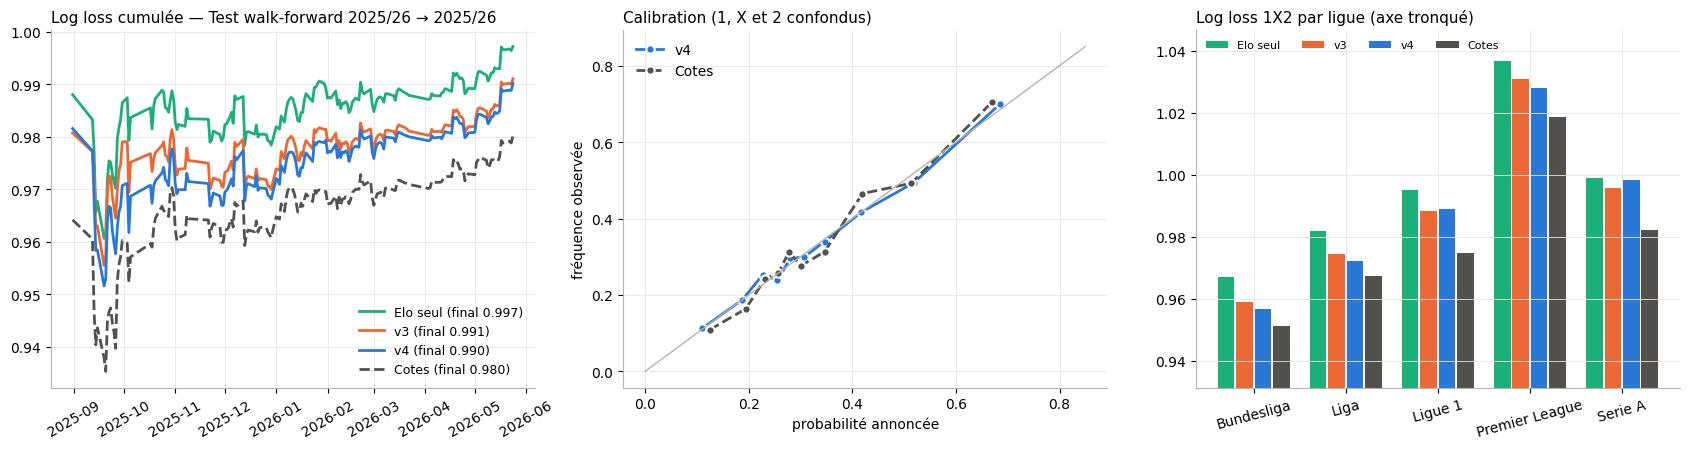

In [3]:
res_s = labo.saison(d, SAISON, LIGUES)
labo.afficher(res_s); labo.enregistrer(res_s, f"saison_{SAISON}"); plt.show()

## 2. La saison rejouée semaine par semaine (≈ 1-2 min)


■ resume


,valeur
log loss v4 ré-entraîné chaque semaine,0.9906
log loss v4 figé,0.9902
log loss cotes,0.9802
gain ré-entraînement ×1e3,0.4023
IC bas,-0.2300
IC haut,1.0066
écart v4 − cotes ×1e3,10.3469
IC bas (cotes),3.6359
IC haut (cotes),17.1262
semaines où v4 bat les cotes,0.4324



■ semaines


,matchs,LL_v4_hebdo,LL_v4_fige,LL_cotes,justes_v4,justes_cotes,cumul_v4_hebdo,cumul_v4_fige,cumul_cotes
semaine du,,,,,,,,,
2025-08-11,24,0.9676,0.9676,0.9696,0.5000,0.5000,0.9676,0.9676,0.9696
2025-08-18,43,0.9945,0.9941,0.9638,0.5116,0.5349,0.9849,0.9846,0.9659
2025-08-25,51,0.9780,0.9776,0.9619,0.5098,0.5490,0.9819,0.9816,0.9642
2025-09-08,42,0.8920,0.8930,0.8734,0.5952,0.6190,0.9583,0.9583,0.9403
2025-09-15,47,0.9811,0.9826,0.9595,0.4255,0.4894,0.9635,0.9639,0.9447
2025-09-22,53,0.9739,0.9730,0.9986,0.4717,0.4528,0.9656,0.9657,0.9557
2025-09-29,52,0.9844,0.9835,0.9643,0.5192,0.5192,0.9687,0.9687,0.9571
2025-10-13,45,0.9844,0.9846,1.0021,0.4889,0.4889,0.9707,0.9707,0.9628
2025-10-20,50,0.9803,0.9802,0.9859,0.5200,0.5200,0.9719,0.9719,0.9656


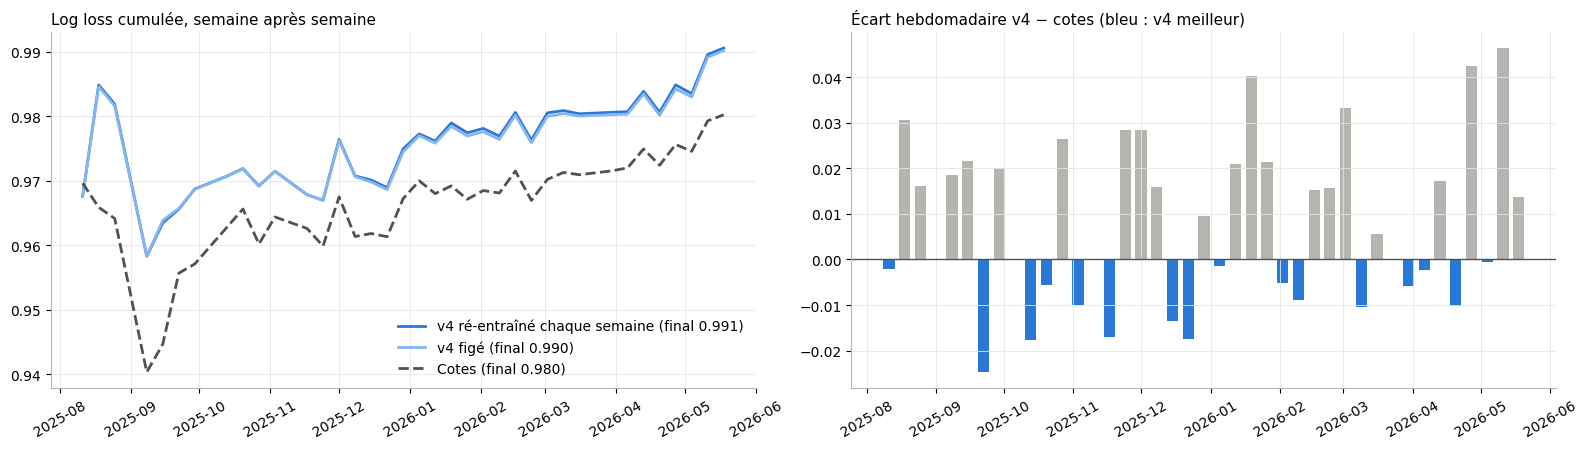

In [4]:
res_h = labo.hebdo(d, SAISON, LIGUES)
labo.afficher(res_h); labo.enregistrer(res_h, f"hebdo_{SAISON}"); plt.show()

## 3. Export Excel pour le rapport

In [5]:
fichier = f"results/labo_saison_{SAISON}.xlsx"
with pd.ExcelWriter(fichier) as xw:
    for nom, res in (("saison", res_s), ("hebdo", res_h)):
        for k, v in res.items():
            if isinstance(v, pd.DataFrame) and not k.startswith("_"): v.to_excel(xw, sheet_name=f"{nom}_{k}"[:31])
print("→", fichier)

→ results/labo_saison_2025.xlsx
